In [3]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
import cv2
import matplotlib.pyplot as plt
from modules_segmentation import *
from modules_augmentation import *
import random
import os

### Load empty image

In [4]:
image_folder = "/user/christoph.wald/u15287/big-scratch/emptyYST"
image_files = os.listdir(image_folder)
empty_YSTs = []
for f in image_files:
    empty_YSTs.append(cv2.imread(os.path.join(image_folder, f)))

### Shear to create augmentations

In [4]:
sheared_YSTs = []
for YST in empty_YSTs:
    sheared_YSTs.append(YST)
    sheared_YSTs.append(random_shear(YST))
    sheared_YSTs.append(random_shear(YST))

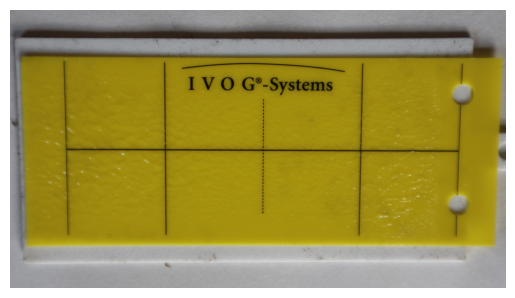

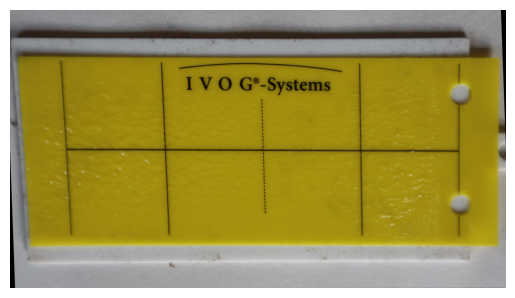

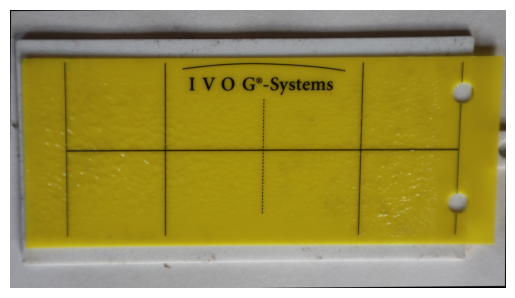

In [5]:
show(sheared_YSTs[0])
show(sheared_YSTs[1])
show(sheared_YSTs[2])

### Create masks to find the areas where to place the insects

In [11]:
processed_mask = cv2.imread(
    #"/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg", 
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/04_generated_mask_fat.jpg",
    cv2.IMREAD_GRAYSCALE
)

gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")

image_files = os.listdir(image_folder)

def get_mask(image, mask, gridcorners, mask_h_line):
    #Load image file
    #print(f"Loading {image_file}")
    #image = cv2.imread(os.path.join(image_folder, image_file))

    #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)
    if len(imagecorners) == 0:
        print(f"No YST found for {image_file}")
        return None

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))
    
    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)

    #second transformation: correct vertical misalignment
    dy = get_distance_h_mid(create_binary_mask(image), mask_h)
    H, W = mask.shape[:2]
    M = np.float32([[1, 0, 0], [0, 1, dy]])  # translation matrix
    mask= cv2.warpAffine(mask, M, (W, H), borderValue=255)  # white background
    return mask[y:y+h, x:x+w]

In [12]:
masks = []
for YST in sheared_YSTs:
    masks.append(get_mask(YST, processed_mask, gridcorners, mask_h_line))



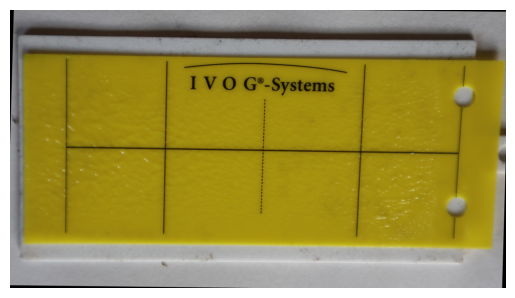

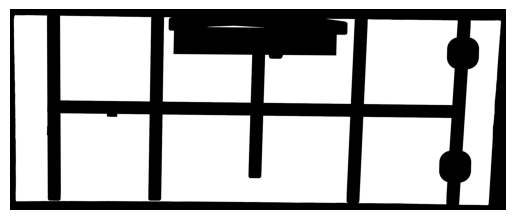

In [13]:
show(sheared_YSTs[1])
show(masks[1])

### get cut out insects

21.0


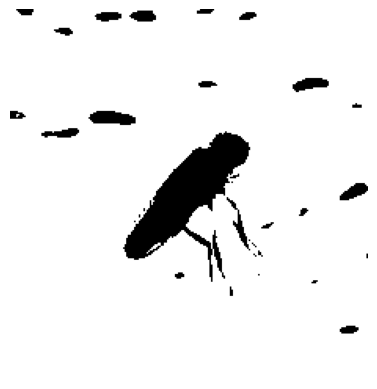

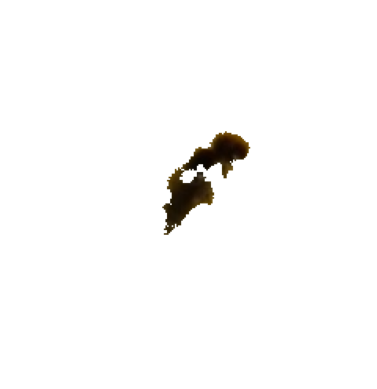

21.0


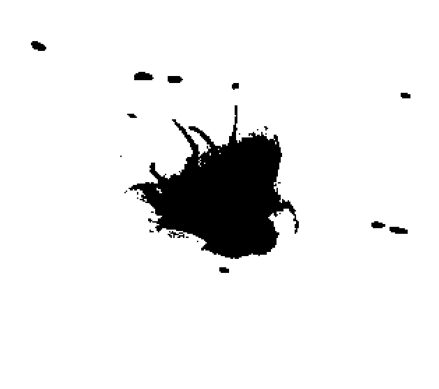

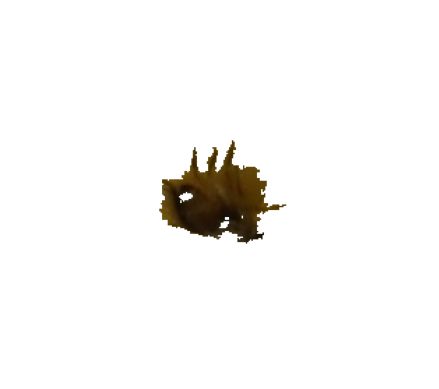

23.0


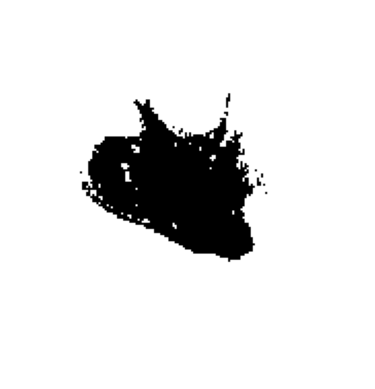

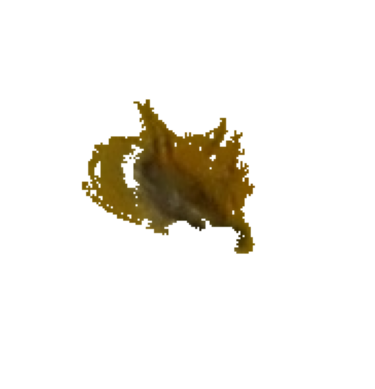

22.0


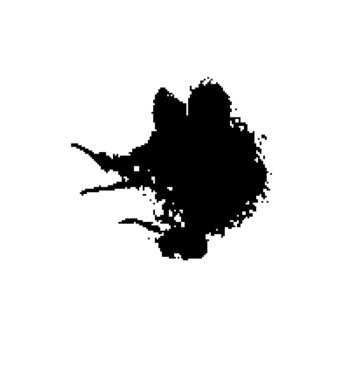

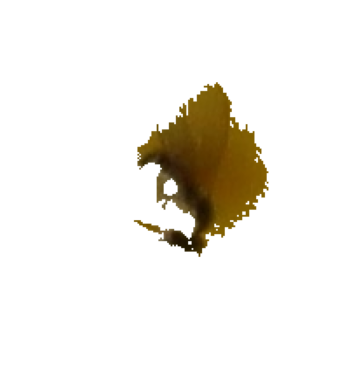

19.0


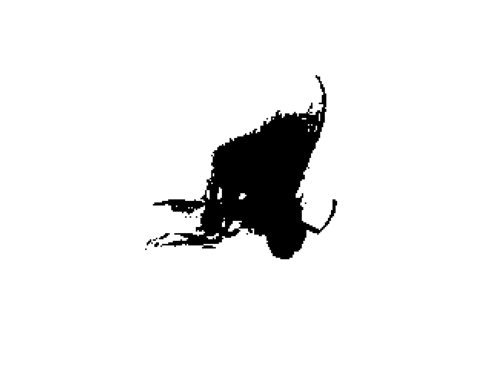

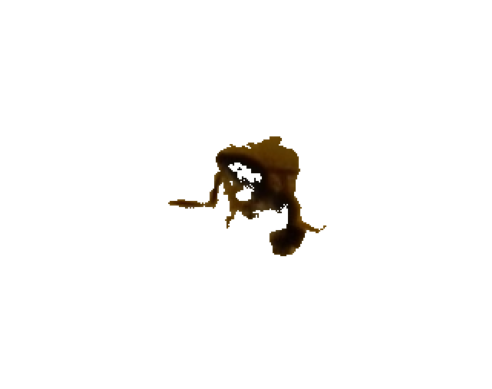

20.0


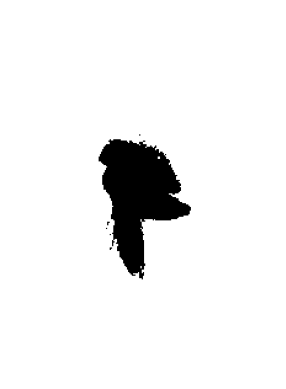

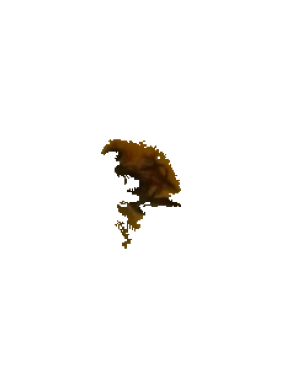

19.0


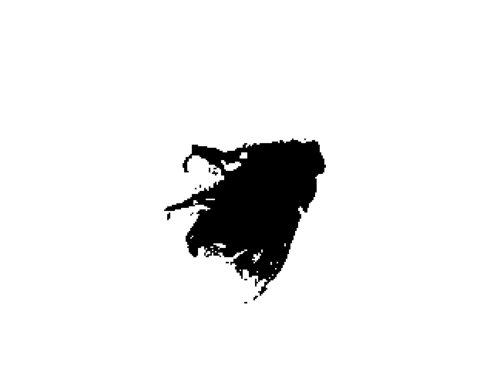

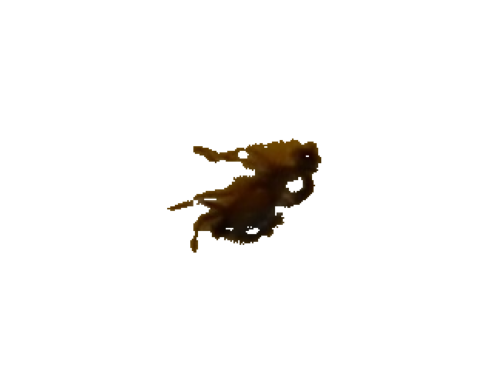

21.0


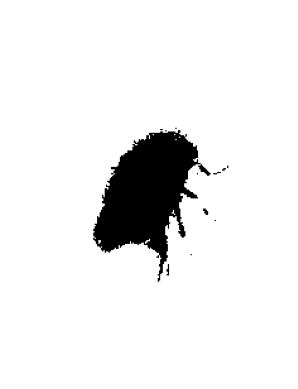

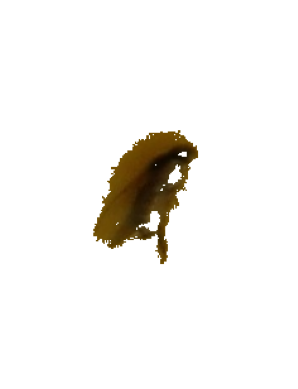

In [ ]:
# Paths
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/05_created_labels"
image_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped"
label_files = os.listdir(label_path)

# Pest types
pest_types = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
all_insects = [[], [], [], []]

counter = 0

for filename in label_files:
    if not filename.startswith("LIRIBO"):
        continue
    if counter == 3:
        continue
    #print(filename)
    cls = [id in filename for id in pest_types].index(True)

    abs_boxes = []
    with open(os.path.join(label_path, filename), 'r') as f:
        for line in f:
            if line.strip():
                x, y, w, h = map(float, ast.literal_eval(line))
                x1, y1, x2, y2 = x, y, x + w, y + h
                abs_boxes.append([x1, y1, x2, y2])

    image = cv2.imread(os.path.join(image_path, os.path.splitext(filename)[0] + ".jpg"))
    rectangles = [enlarge_box(box, image.shape, scale=1) for box in abs_boxes]

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    insects = []

    for box in rectangles:
        x1, y1, x2, y2 = map(int, box)
        region_bgr = image[y1:y2, x1:x2]
        if region_bgr.size == 0:
            continue

        region_hsv = hsv_image[y1:y2, x1:x2]         

        value = region_hsv[:, :, 2]
        otsu_thresh, binary_mask = cv2.threshold(value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        #binary_mask_inv = cv2.bitwise_not(binary_mask)
        
        hue = region_hsv[:, :, 0]

        t, hue_mask = cv2.threshold(hue, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        print(t)
        #hue_mask = cv2.bitwise_not(hue_mask)
        lower_yellow = np.array([18, 100, int(otsu_thresh)])
        upper_yellow = np.array([30, 255, 255])
        
        binary_mask = cv2.inRange(region_hsv, lower_yellow, upper_yellow)
        binary_mask_inv = cv2.bitwise_not(binary_mask)
        
        foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask_inv)
        background = np.full_like(region_bgr, 255)
        result = np.where(binary_mask_inv[:, :, np.newaxis] == 0, background, foreground)
        result = keep_central_contour(result)
        show(result)
        # ✅ Keep only the main (central) contour


        insects.append(result)
    counter +=1
    all_insects[cls].extend(insects)

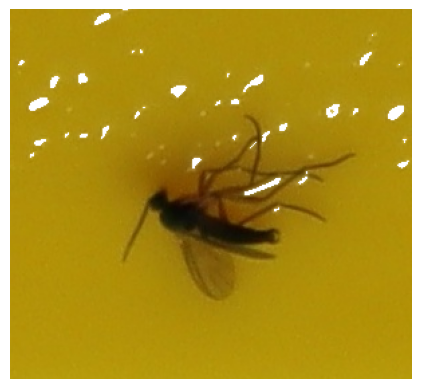

In [17]:
show(all_insects[0][0])

In [9]:
# Paths
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/05_created_labels"
image_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped"
label_files = os.listdir(label_path)

# Pest types
pest_types = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
all_insects = [[], [], [], []]
counter = 0

for filename in label_files:
    if not filename.startswith("TRIAVA"):
        continue
    #print(filename)
    counter += 1
    cls = [id in filename for id in pest_types].index(True)

    abs_boxes = []
    with open(os.path.join(label_path, filename), 'r') as f:
        for line in f:
            if line.strip():
                x, y, w, h = map(float, ast.literal_eval(line))
                x1, y1, x2, y2 = x, y, x + w, y + h
                abs_boxes.append([x1, y1, x2, y2])

    image = cv2.imread(os.path.join(image_path, os.path.splitext(filename)[0] + ".jpg"))
    rectangles = [enlarge_box(box, image.shape, scale=1) for box in abs_boxes]

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    insects = []

    for box in rectangles:
        x1, y1, x2, y2 = map(int, box)
        region_bgr = image[y1:y2, x1:x2]
        if region_bgr.size == 0:
            continue
        
        
        
        region_hsv = hsv_image[y1:y2, x1:x2]
        #show(region_bgr)
        binary_mask = create_binary_mask(region_hsv)

        # Apply mask
        foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask)
        background = np.full_like(region_bgr, 255)
        result = np.where(binary_mask[:, :, np.newaxis] == 0, background, foreground)
        #show(result)

        # Step 1: Convert to grayscale to detect white pixels
        gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
        white_mask = (gray >= 250).astype(np.uint8)  # 1 = white, 0 = non-white

        # Step 2: Create a copy to visualize
        visual = result.copy()

        # Step 3: Prepare mask for floodFill (2 pixels larger)
        h, w = white_mask.shape
        flood_mask = np.zeros((h+2, w+2), np.uint8)

        # Step 4: Flood-fill all border-connected white pixels in red
        for x in range(w):
            if white_mask[0, x]:
                cv2.floodFill(visual, flood_mask, (x, 0), (0, 0, 255))  # red
            if white_mask[h-1, x]:
                cv2.floodFill(visual, flood_mask, (x, h-1), (0, 0, 255))
        for y in range(h):
            if white_mask[y, 0]:
                cv2.floodFill(visual, flood_mask, (0, y), (0, 0, 255))
            if white_mask[y, w-1]:
                cv2.floodFill(visual, flood_mask, (w-1, y), (0, 0, 255))

        # Step 5: Find internal white pixels (still white in visual)
        internal_white_mask = np.all(visual == result, axis=2) & (white_mask == 1)

        # Step 6: Color internal white pixels blue
        visual[internal_white_mask] = (255, 0, 0)  # BGR blue

        # Show the result
        #show(visual)

        
        # Step 1: Identify blue pixels in visual (internal white)
        blue_mask = (visual[:, :, 0] == 255) & (visual[:, :, 1] == 0) & (visual[:, :, 2] == 0)

        # Step 2: Start from the current result
        merged = result.copy()

        # Step 3: Replace only blue pixels with original colors from region_bgr
        merged[blue_mask] = region_bgr[blue_mask]

        # Step 4: Show or return
        #show(merged)



        # Skip mostly white boxes
        non_white = np.any(result < 250, axis=2)
        non_white_ratio = np.sum(non_white) / non_white.size
        if non_white_ratio < 0.05:
            continue

        result = keep_central_contour(merged)

        insects.append(result)


    all_insects[cls].extend(insects)

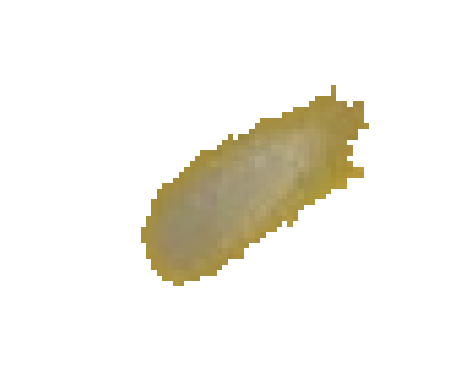

In [11]:
show(all_insects[3][1])

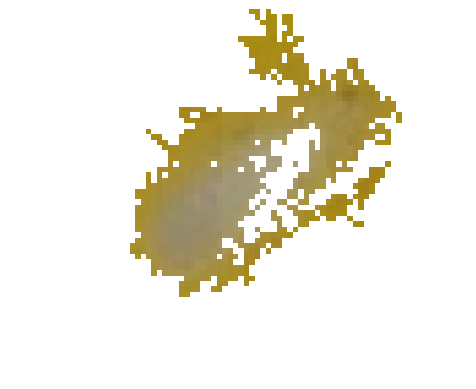

In [97]:
show(all_insects[3][1])

### Place the insects

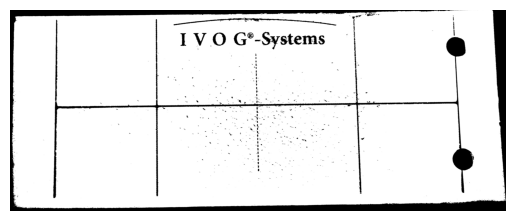

Placing insect index: 43
Placing insect index: 553
Placing insect index: 742
Placing insect index: 2329
Placing insect index: 463
Placing insect index: 1227
Placing insect index: 129
Placing insect index: 2223
Placing insect index: 554
Placing insect index: 2558
Placing insect index: 1364
Placing insect index: 1474
Placing insect index: 516
Placing insect index: 223
Placing insect index: 1905
Placing insect index: 1818
Placing insect index: 671
Placing insect index: 926
Placing insect index: 2036
Placing insect index: 1881
Placing insect index: 710
Placing insect index: 1546


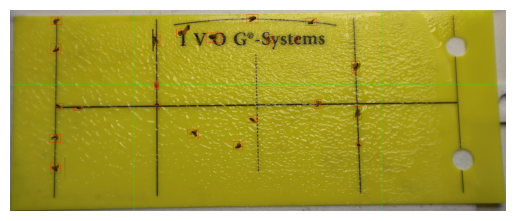

In [ ]:
empty_YST = sheared_YSTs[10].copy()
imageYST = find_contour(empty_YST)
x, y, w, h = cv2.boundingRect(imageYST)
empty_YST_cropped = empty_YST[y:y+h, x:x+w]
mask = create_binary_mask(empty_YST_cropped)

show(mask)
mask_binary = (mask < 128).astype(np.uint8)
mask_binary = remove_border_connected(mask_binary)
place_insects_by_region(empty_YST_cropped, mask_binary, all_insects[1],4)
show(empty_YST_cropped)


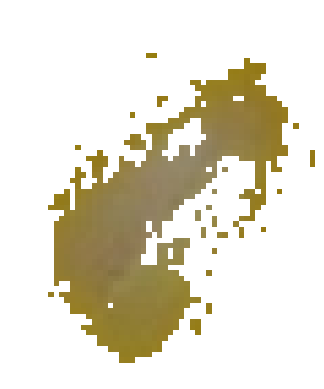

In [161]:
show(all_insects[3][0])

### The other idea: Place background behind existing tiles

In [2]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
import cv2
import matplotlib.pyplot as plt
from modules_segmentation import *
from modules_augmentation import *
import random
import os

In [7]:
def crop(image):
    mask = create_binary_mask(image)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_image = image[y:y+h, x:x+w]
        return cropped_image, (x, y, w, h)
    else:
        return None, None
    
def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()

def fit_mask_to_image(mask, img_shape):
    """
    Resize/crop or place mask to fit the image shape.
    If mask is smaller: place randomly.
    If mask is larger: crop to fit.
    """
    mask_h, mask_w = mask.shape
    img_h, img_w = img_shape[:2]

    # If mask is larger, crop it
    if mask_h > img_h:
        start_y = (mask_h - img_h) // 2
        mask = mask[start_y:start_y+img_h, :]
    if mask_w > img_w:
        start_x = (mask_w - img_w) // 2
        mask = mask[:, start_x:start_x+img_w]

    # If mask is smaller, place it randomly
    mask_h, mask_w = mask.shape
    result_mask = np.ones((img_h, img_w), dtype=mask.dtype) * 255  # white background
    max_y = img_h - mask_h
    max_x = img_w - mask_w
    start_y = random.randint(0, max_y) if max_y > 0 else 0
    start_x = random.randint(0, max_x) if max_x > 0 else 0
    result_mask[start_y:start_y+mask_h, start_x:start_x+mask_w] = mask
    return result_mask

def circular_shift_mask_2d(mask, min_shift=500):
    h, w = mask.shape
    max_shift_h = h // 2
    max_shift_w = w // 2
    shift_y = random.randint(min_shift, max_shift_h) * random.choice([-1, 1])
    shift_x = random.randint(min_shift, max_shift_w) * random.choice([-1, 1])
    shifted_mask = np.roll(mask, shift_y, axis=0)
    shifted_mask = np.roll(shifted_mask, shift_x, axis=1)
    return shifted_mask

In [4]:
image_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped"
filenames = os.listdir(image_path)
sorted_filenames = [[], [], []]
nums = []
species = ["BRAIIM", "LIRIBO", "TRIAVA"]
for i in range(3):
    for f in filenames:
        if f.startswith(species[i]):
            sorted_filenames[i].append(f)

random_filenames = []
for i in range(3):
    random_filenames.extend(random.sample(sorted_filenames[i], len(sorted_filenames[i])//2))

(3368, 6000, 3)
(2143, 4568)


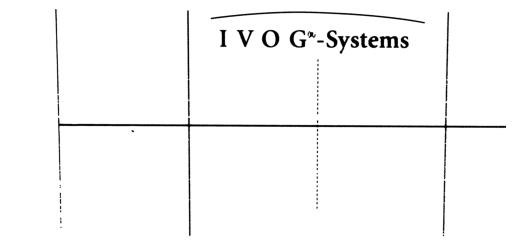

(3368, 6000, 3)
(2127, 4558)


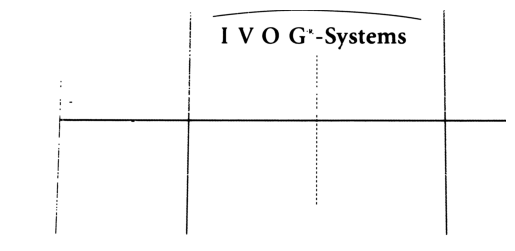

(3368, 6000, 3)
(2135, 4602)


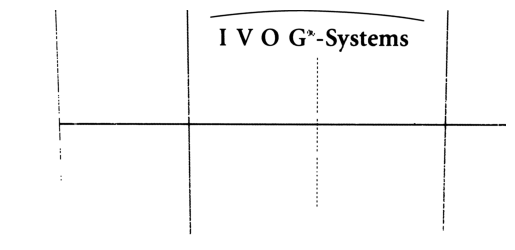

In [8]:
empty_folder = "/user/christoph.wald/u15287/big-scratch/emptyYST"
filenames = os.listdir(empty_folder)[:3]
masks = []
for f in filenames:
    img = cv2.imread(os.path.join(empty_folder, f))
    print(img.shape)
    empty_YST, _ = crop(img)
    mask = create_binary_mask(empty_YST)
    cleaned_mask = denoise_mask(mask)
    h, w = cleaned_mask.shape

    top = 75
    bottom = h - 100
    left = 100
    right = w * 4 // 5  # remove the rightmost 1/5

    cleaned_mask = cleaned_mask[top:bottom, left:right]
    print(cleaned_mask.shape)

    masks.append(cleaned_mask)
    show(cleaned_mask)

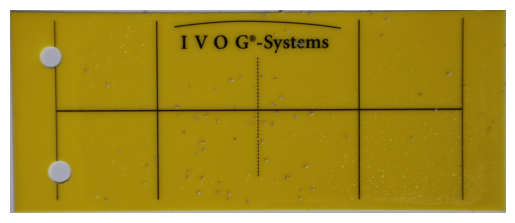

In [102]:
#for each image
img = cv2.imread(os.path.join(image_path, random_filenames[300]))
show(img)

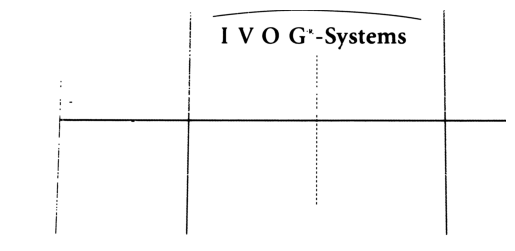

In [105]:
mask = masks[random.randint(0,3)]
show(mask)

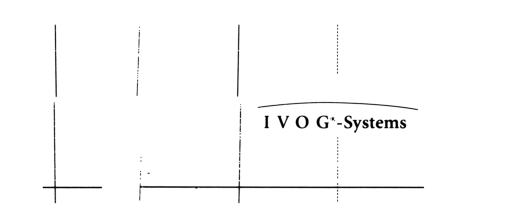

In [106]:
mask = circular_shift_mask_2d(mask)
mask = fit_mask_to_image(mask, img.shape)
show(mask)

In [107]:
mask0 = mask

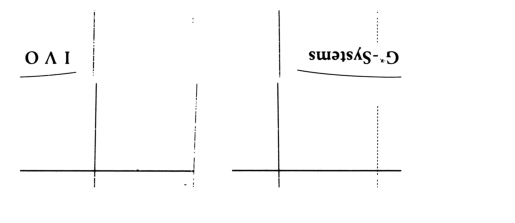

In [108]:
mask = masks[random.randint(0,3)]
mask = circular_shift_mask_2d(mask)
mask = cv2.rotate(mask, cv2.ROTATE_180)
mask = fit_mask_to_image(mask, img.shape)
show(mask)


In [109]:
mask1 = mask

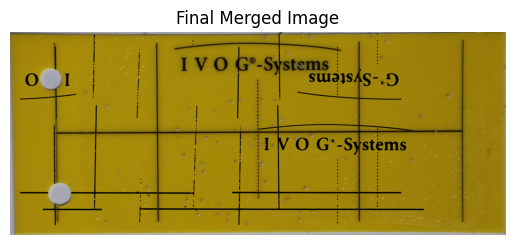

In [110]:
# --- Create yellow/background mask from the image ---
yellow_mask = create_binary_mask(img)  # 255 = background
yellow_mask_3c = cv2.merge([yellow_mask]*3)

# --- Create black lines mask from shifted mask ---
line_mask = (mask0 == 0).astype(np.uint8) * 255
line_mask_3c0 = cv2.merge([line_mask]*3)

line_mask = (mask1 == 0).astype(np.uint8) * 255
line_mask_3c1 = cv2.merge([line_mask]*3)


# --- Build the merged image ---
# Step 1: Background
background_layer = img.copy()
background_layer[yellow_mask_3c == 0] = 0

# Step 2: Overlay black lines
merged = background_layer.copy()
merged[line_mask_3c0 == 255] = 0  # black lines
merged[line_mask_3c1 == 255] = 0  # black lines

# Step 3: Restore foreground from original image
foreground_layer = np.zeros_like(img)
foreground_layer[yellow_mask_3c == 0] = img[yellow_mask_3c == 0]
merged[yellow_mask_3c == 0] = img[yellow_mask_3c == 0]

show(merged, "Final Merged Image")

In [101]:
cv2.imwrite("test.jpg", merged) 

True